In [1]:
import os

# Define the names of the directories to be created
directory_name_1 = "frames"
directory_name_2 = "filter_frames"

# Create the first directory
os.makedirs(directory_name_1, exist_ok=True)
print(f"Directory '{directory_name_1}' created successfully.")

# Create the second directory
os.makedirs(directory_name_2, exist_ok=True)
print(f"Directory '{directory_name_2}' created successfully.")

# You can verify the creation using a shell command
print("\nVerifying directory creation:")
!ls

Directory 'frames' created successfully.
Directory 'filter_frames' created successfully.

Verifying directory creation:
filter_frames  frames  sample_data


In [ ]:
!git clone https://github.com/facebookresearch/sam2.git && cd sam2



Cloning into 'sam2'...
remote: Enumerating objects: 1070, done.
remote: Total 1070 (delta 0), reused 0 (delta 0), pack-reused 1070 (from 1)
Receiving objects: 100% (1070/1070), 128.11 MiB | 38.82 MiB/s, done.
Resolving deltas: 100% (381/381), done.


In [ ]:
%cd sam2

/content/sam2


In [ ]:
!pip install -e .

Obtaining file:///content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.9 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=13852 sha256=3f448f65ab89bff405c8312018e10a1956783cb4fa6e1c9acb6dce3e0f9c4309
  Stored in directory: /tmp/pip-ephem-wheel-cache-05za75e5/wheels/9e/fa/17/14aaeb20d3ca07c58ee93742054d4479f89c243063ce0b61b9
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=893ac6ea625065c94d7e7dba6dde3b88b2f5a8ff79199f4cd3b5d2a277cef703
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
CUDA is available: True


In [ ]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
import sys
sys.path.append('./sam2')

In [ ]:
!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

--2025-11-26 18:06:10--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.227.219.59, 13.227.219.10, 13.227.219.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.227.219.59|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 898083611 (856M) [application/vnd.snesdev-page-table]
Saving to: ‘../checkpoints/sam2.1_hiera_large.pt’

sam2.1_hiera_large. 100%[===================>] 856.48M  63.4MB/s    in 13s     

2025-11-26 18:06:22 (68.1 MB/s) - ‘../checkpoints/sam2.1_hiera_large.pt’ saved [898083611/898083611]



In [ ]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [ ]:
!ffmpeg -i /content/sample.mov -q:v 2 -start_number 0  /content/frames/'%05d.jpg'



ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

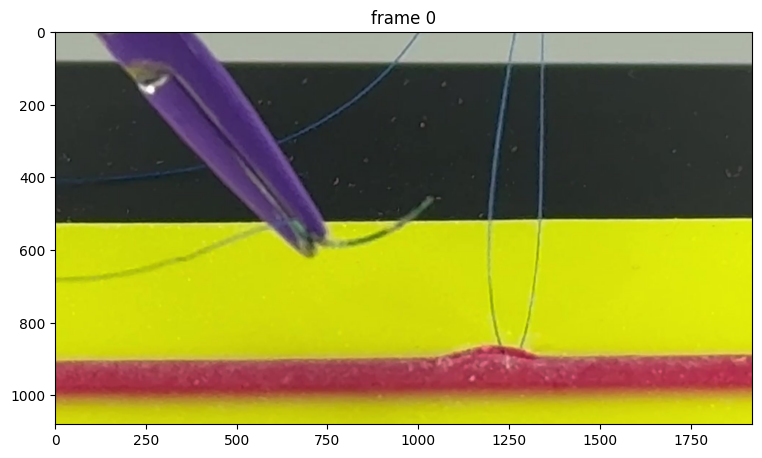

In [ ]:
import os
from PIL import Image
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "/content/frames"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx =0


plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [ ]:
import os
import shutil
image_files = sorted(os.listdir(video_dir))

for i, filename in enumerate(image_files):
    # if i % 5== 0:
      src_path = os.path.join("/content/frames", filename)
      dst_path = os.path.join("/content/filter_frames", filename)
      shutil.copy2(src_path, dst_path)  # copy2 keeps metadata



In [ ]:
image_files = sorted(os.listdir("/content/filter_frames"))


In [ ]:
len(image_files)

485

end

In [ ]:
inference_state = predictor.init_state(video_path="/content/filter_frames")

frame loading (JPEG): 100%|██████████| 485/485 [00:23<00:00, 20.47it/s]


In [ ]:
predictor.reset_state(inference_state)

In [ ]:
prompts = {}  # hold all the clicks we add for visualization


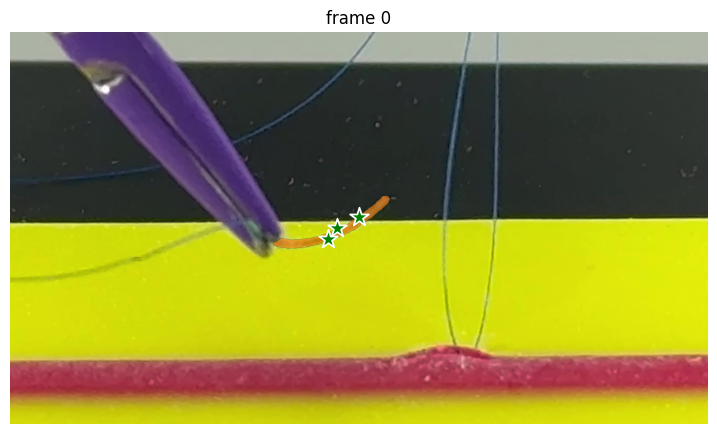

In [ ]:
ann_frame_idx = 0      # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[875,570],[900,540],[960,510]], dtype=np.float32)
labels  = np.array([1,1,1], dtype=np.int32)   # 1 = foreground

# # Negative click ON the thread (or any background) near the needle
# neg_points  = np.array([[1010, 490]], dtype=np.float32)
# neg_labels  = np.array([0], dtype=np.int32)   # 0 = background

# Stack them so SAM gets both prompts at once
# points = np.concatenate([pos_points,  neg_points],  axis=0)
# labels = np.concatenate([pos_labels,  neg_labels],  axis=0)
# box = np.array([500, 800, 600, 900], dtype=np.float32)


# box = np.array([1100, 700, 1390, 790], dtype=np.float32)
prompts[ann_obj_id] = points, labels

# --- 2) run SAM -----------------------------------------------------
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


In [ ]:
out_obj_ids

[1]

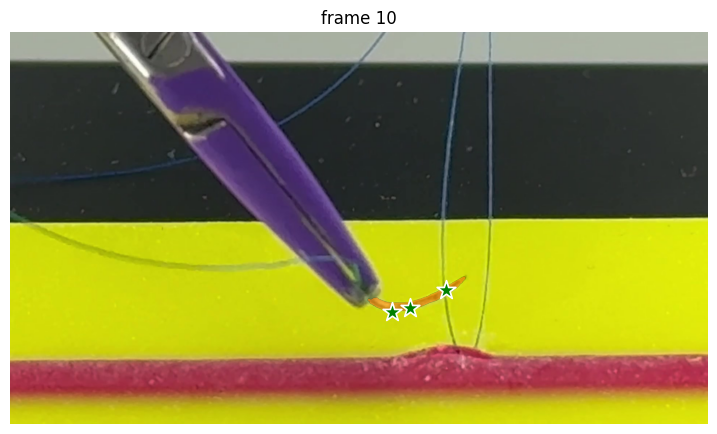

In [ ]:
ann_frame_idx = 10      # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[1100,760],[1200,710],[1050,770]], dtype=np.float32)
labels  = np.array([1,1,1], dtype=np.int32)   # 1 = foreground

#prompts[ann_obj_id] = points, labels

_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


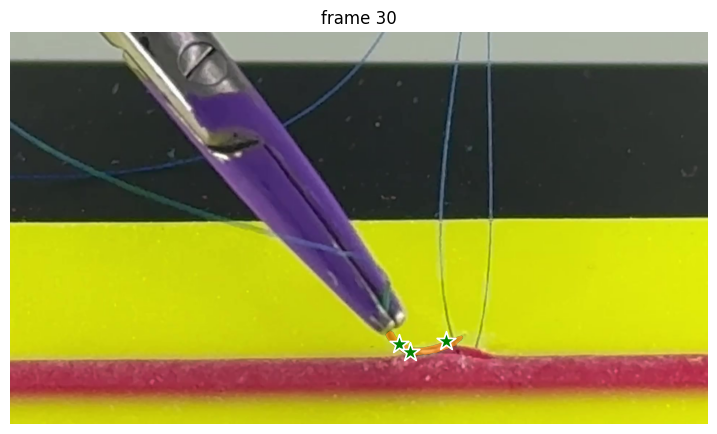

In [ ]:
ann_frame_idx = 30     # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[1070,860],[1100,880],[1200,850]], dtype=np.float32)
labels  = np.array([1,1,1], dtype=np.int32)   # 1 = foreground
#prompts[ann_obj_id] = points, labels

# # Negative click ON the thread (or any background) near the needle
# neg_points  = np.array([[1010, 490]], dtype=np.float32)
# neg_labels  = np.array([0], dtype=np.int32)   # 0 = background

# Stack them so SAM gets both prompts at once
# points = np.concatenate([pos_points,  neg_points],  axis=0)
# labels = np.concatenate([pos_labels,  neg_labels],  axis=0)
# box = np.array([500, 800, 600, 900], dtype=np.float32)


# box = np.array([1100, 700, 1390, 790], dtype=np.float32)

# --- 2) run SAM -----------------------------------------------------
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


In [ ]:
# show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
#           plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
# arr = (out_mask_logits[0]>0.0).cpu().numpy().astype("uint8")
# arr[0][900][1000:1920]

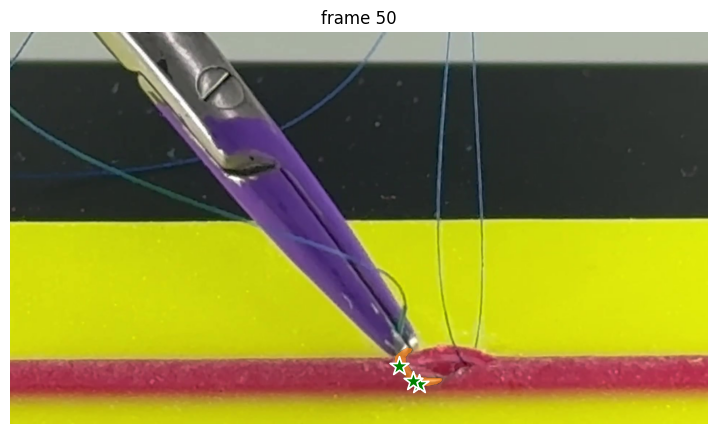

In [ ]:
ann_frame_idx = 50      # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[1070,920],[1125,970],[1110,960]], dtype=np.float32)
labels  = np.array([1,1,1], dtype=np.int32)   # 1 = foreground

#prompts[ann_obj_id] = points, labels

_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


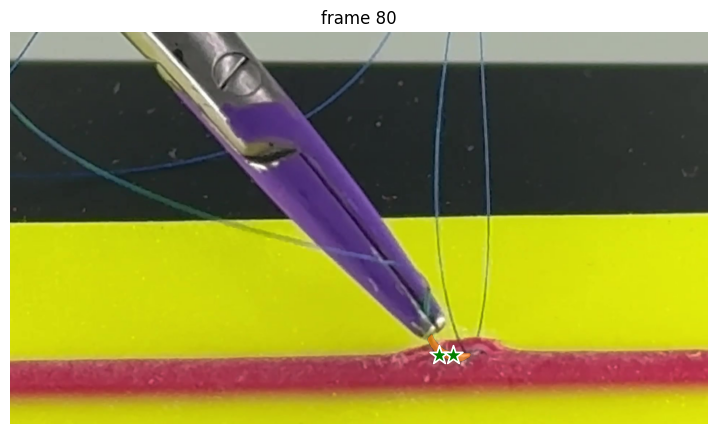

In [ ]:
ann_frame_idx = 80      # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[1180,890],[1220,890]], dtype=np.float32)
labels  = np.array([1,1], dtype=np.int32)   # 1 = foreground
#prompts[ann_obj_id] = points, labels

# [1200,880],[1210,870]
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


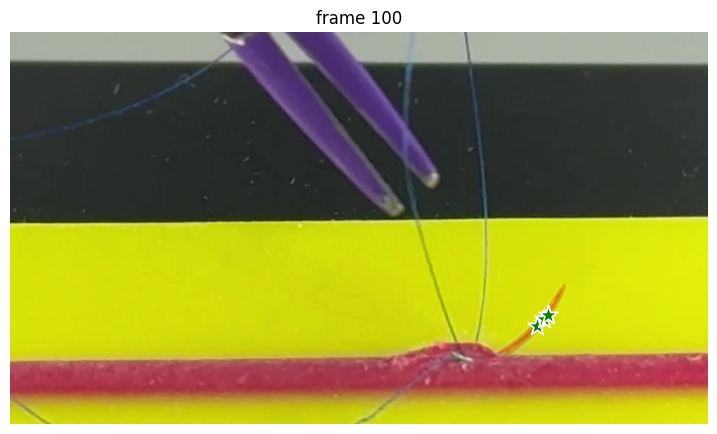

In [ ]:
ann_frame_idx = 100    # frame we interact with
ann_obj_id   = 1        # unique id for the needle object

# --- 1) define prompts ---------------------------------------------
# Positive click ON the needle tip/shank
points  = np.array([[1450,810],[1470,790],[1480,780]], dtype=np.float32)
labels  = np.array([1,1,1], dtype=np.int32)   # 1 = foreground
#prompts[ann_obj_id] = points, labels

# [1200,880],[1210,870]
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state = inference_state,
    frame_idx       = ann_frame_idx,
    obj_id          = ann_obj_id,
    points          = points,
    labels          = labels,
    #  box             = box
)

# --- 3) visualize ---------------------------------------------------
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_box(box, plt.gca())
show_points(points, labels, plt.gca())                       # green = pos, red = neg
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(),
          plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


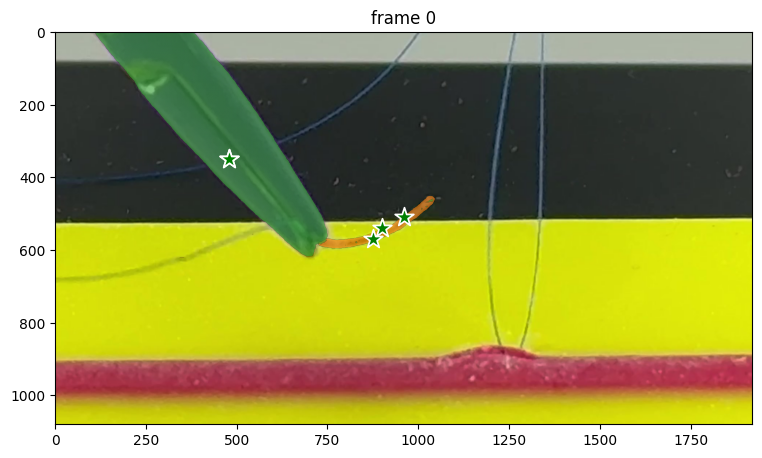

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

# Let's now move on to the second object we want to track (giving it object id `3`)
# with a positive click at (x, y) = (400, 150)
points = np.array([[480,350]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], np.int32)
prompts[ann_obj_id] = points, labels

# `add_new_points_or_box` returns masks for all objects added so far on this interacted frame
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame on all objects
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

propagate in video: 100%|██████████| 485/485 [00:30<00:00, 16.16it/s]
/tmp/ipython-input-1961725956.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


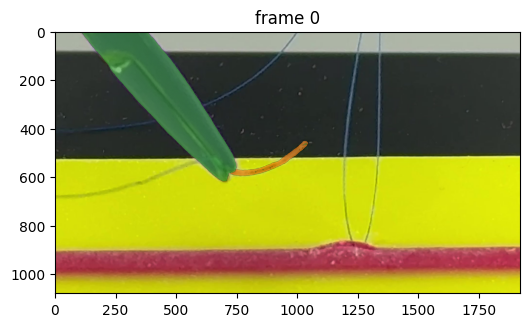

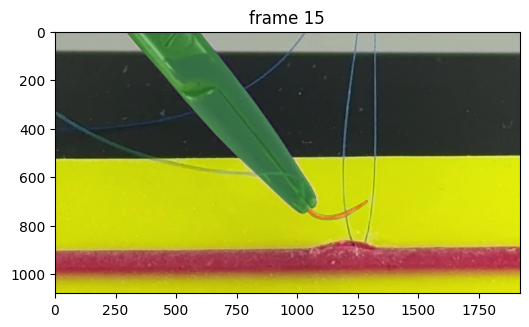

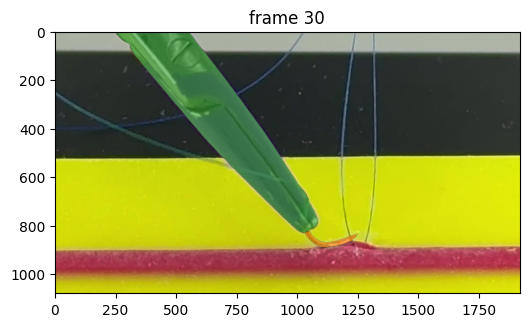

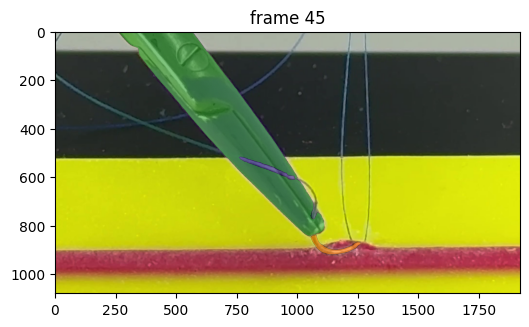

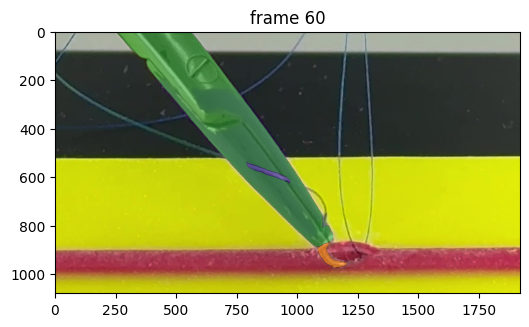

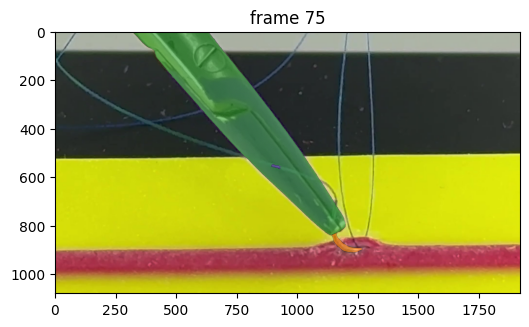

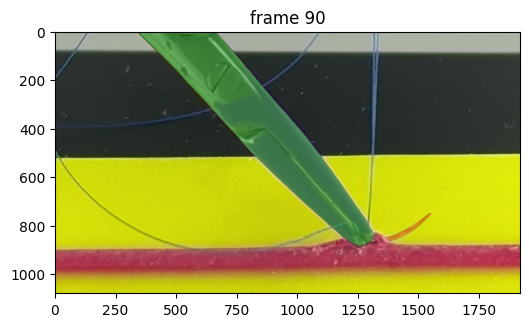

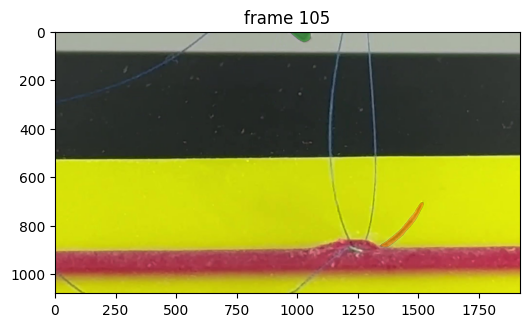

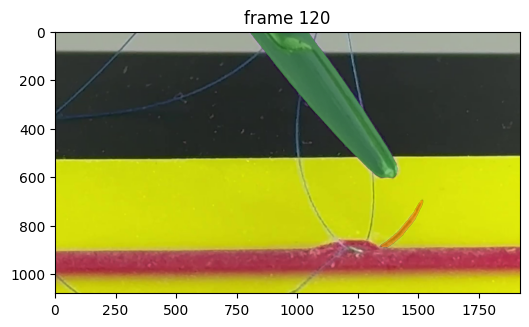

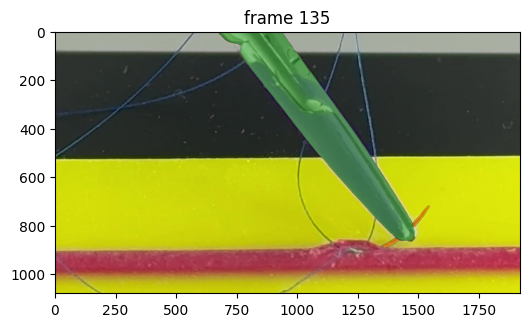

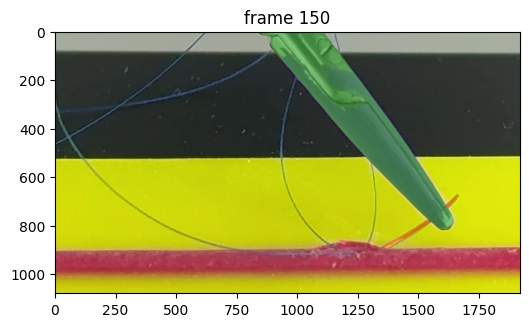

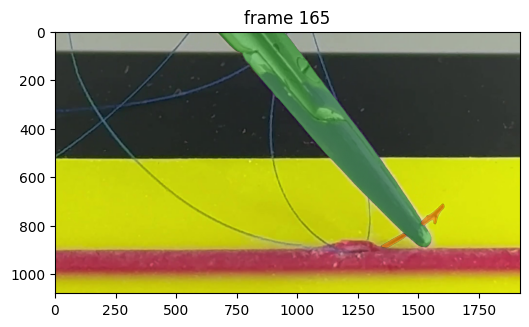

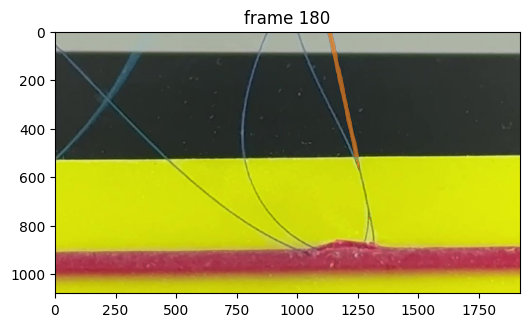

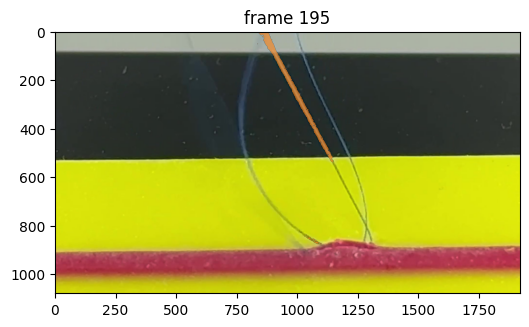

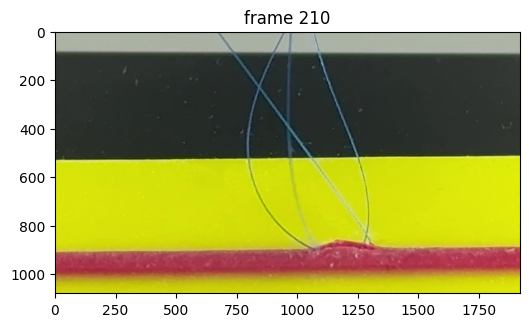

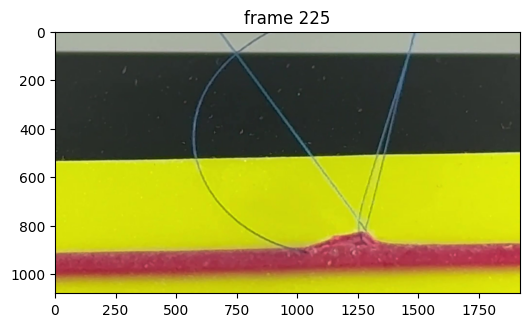

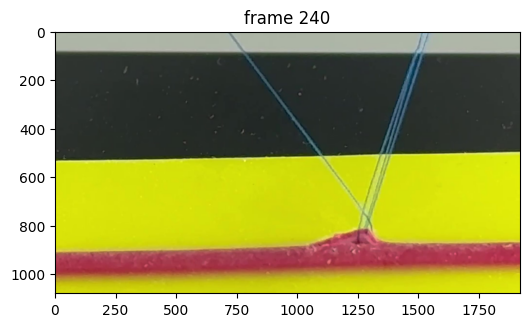

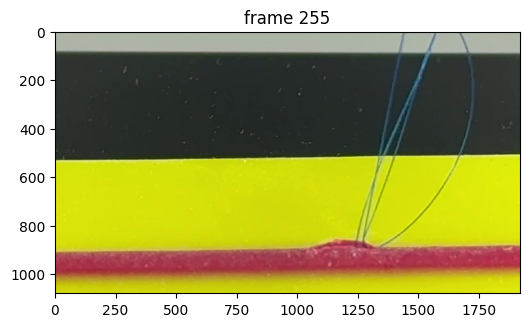

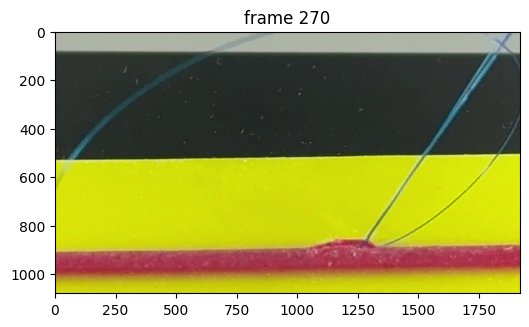

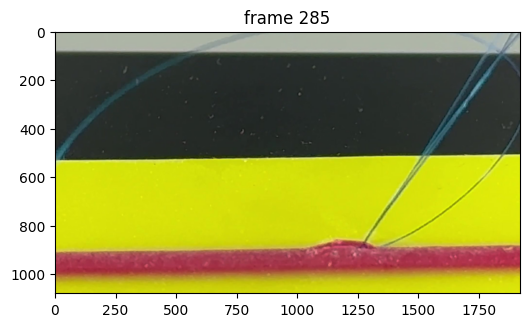

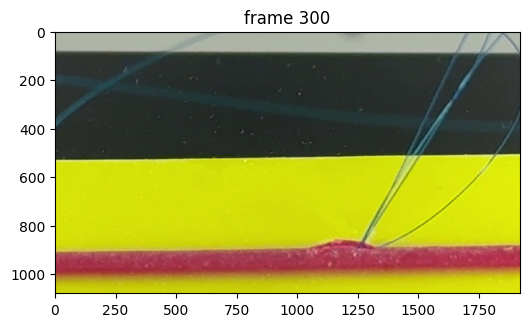

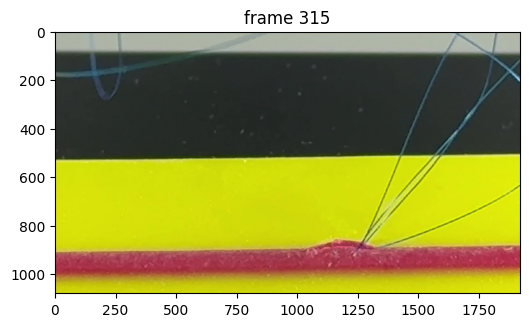

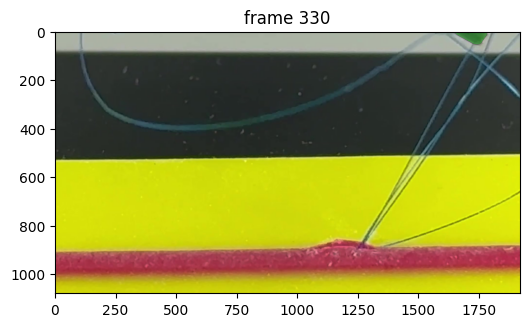

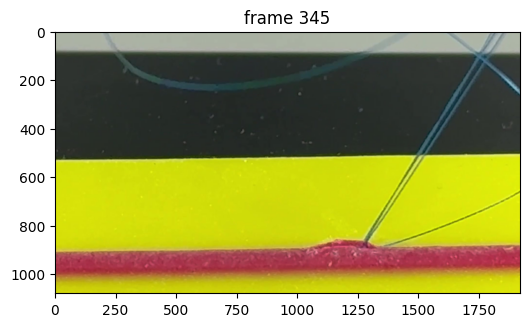

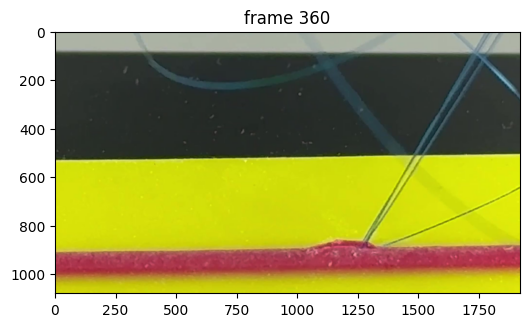

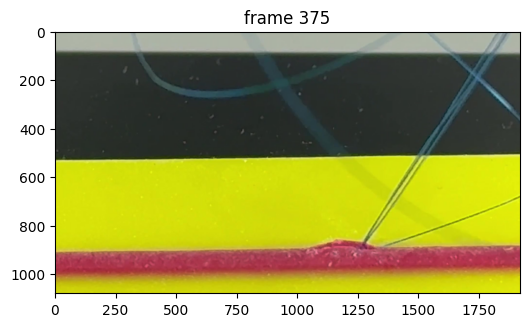

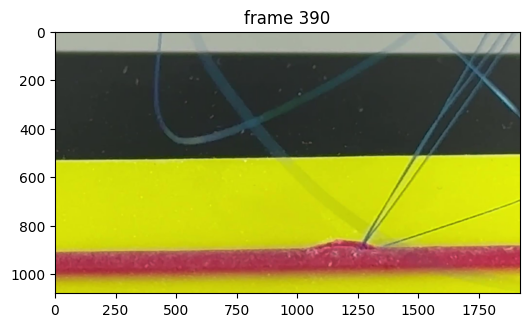

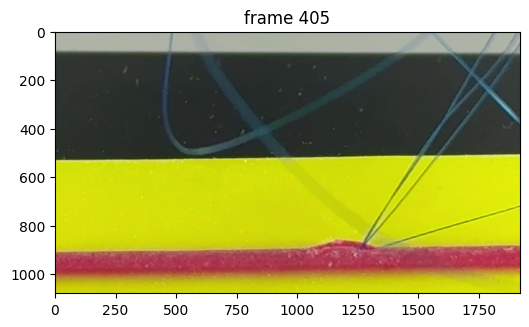

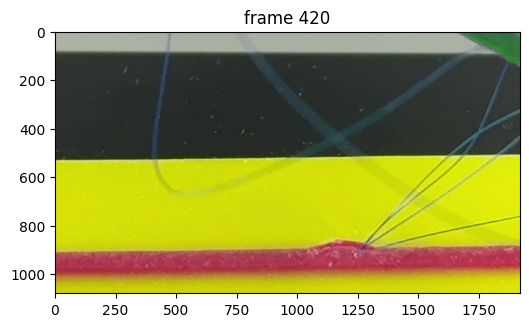

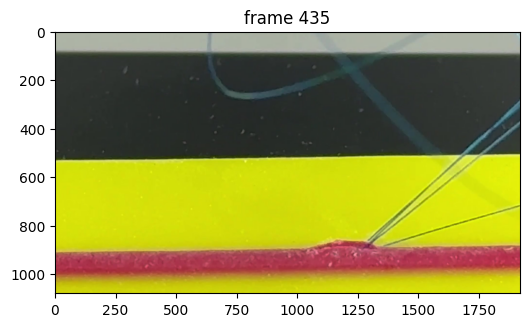

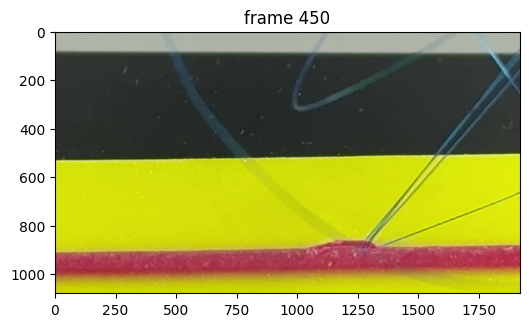

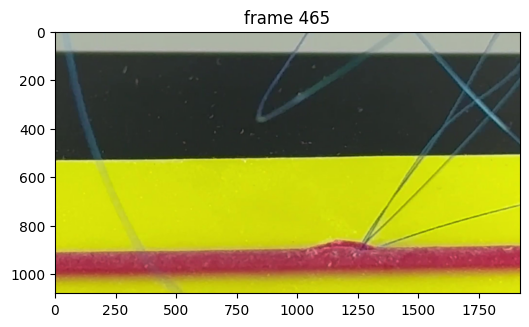

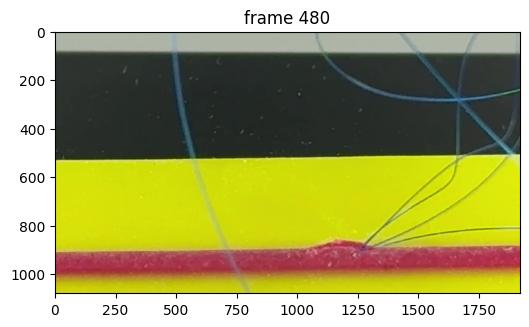

In [ ]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):

    video_segments[out_frame_idx] = {

        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
    # for i, out_obj_id in enumerate(out_obj_ids):
    #      print( (out_mask_logits[i] > 0.0).cpu().numpy().astype("uint8"))


# render the segmentation results every few frames
vis_frame_stride = 15
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    if out_frame_idx in video_segments:
      for out_obj_id, out_mask in video_segments[out_frame_idx].items():
          show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [ ]:
needle_masks = []
forceps_masks = []
# mask = np.squeeze(mask)          # ensure (H, W)
# y, x = np.where(mask)
for index , l in enumerate( video_segments):
   needle_masks.append(np.squeeze(video_segments[index][1])  )

for index , l in enumerate( video_segments):
   forceps_masks.append(np.squeeze(video_segments[index][2])  )



In [ ]:
import numpy as np
from scipy.ndimage import center_of_mass
from sklearn.decomposition import PCA

def get_centroid(mask):
    """Return centroid (y, x) or None if no needle detected."""
    if mask.sum() == 0:
        return None
    return center_of_mass(mask)

def get_orientation(mask):
    """Return orientation angle in radians using PCA."""
    y, x = np.where(mask)
    if len(x) < 2:
        return None
    pca = PCA(n_components=2).fit(np.column_stack([x, y]))
    return np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

def analyze_skill(masks):
    """
    masks: list or array of binary masks (N_frames, H, W)
    returns: dictionary of skill metrics
    """
    centroids = []
    orientations = []

    for mask in masks:
        mask = np.squeeze(mask)  # ensure (H, W)
        centroids.append(get_centroid(mask))
        orientations.append(get_orientation(mask))

    # filter valid points
    valid_centroids = np.array([c for c in centroids if c is not None])
    valid_orientations = np.array([o for o in orientations if o is not None])

    if len(valid_centroids) < 2:
        return {"error": "Not enough needle detections"}

    # --- Skill Metrics ---
    # Path length
    diffs = np.diff(valid_centroids, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_length = distances.sum()

    # Speed (mean displacement per frame)
    mean_speed = distances.mean()

    # Acceleration & Jerk
    velocity = distances
    acceleration = np.diff(velocity)
    jerk = np.diff(acceleration)
    mean_jerk = np.mean(np.abs(jerk)) if len(jerk) > 0 else 0

    # Smoothness (std of displacement)
    smoothness = distances.std()

    # Orientation variability
    orientation_variability = np.nanstd(valid_orientations)

    return {
        "path_length": path_length,
        "mean_speed": mean_speed,
        "movement_smoothness": smoothness,
        "orientation_variability": orientation_variability,
        "trajectory": valid_centroids,
        "orientations": valid_orientations,
        "mean_jerk": mean_jerk

    }


In [ ]:
# Suppose masks is your array: shape (N_frames, 1080, 1920)
results = analyze_skill(needle_masks)

print("Path Length:", results["path_length"])
print("Mean Speed:", results["mean_speed"])
print("Movement Smoothness:", results["movement_smoothness"])
print("Mean Jerk:", results["mean_jerk"])
print("Orientation Variability:", results["orientation_variability"])

Path Length: 7446.516213962453
Mean Speed: 34.7968047381423
Movement Smoothness: 121.36470023132522
Mean Jerk: 43.55871230724079
Orientation Variability: 1.0309805877978153


In [ ]:
# Suppose masks is your array: shape (N_frames, 1080, 1920)
results = analyze_skill(forceps_masks)

print("Path Length:", results["path_length"])
print("Mean Speed:", results["mean_speed"])
print("Movement Smoothness:", results["movement_smoothness"])
print("Mean Jerk:", results["mean_jerk"])
print("Orientation Variability:", results["orientation_variability"])

Path Length: 7008.851669377125
Mean Speed: 34.526362903335595
Movement Smoothness: 72.12151154943035
Mean Jerk: 41.1298798851023
Orientation Variability: 0.20154283108316826


1).Compute Centroids (Needle & Forceps)

In [ ]:
import numpy as np

def centroid(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return np.mean(xs), np.mean(ys)


2). Extract Trajectories From All Frames

In [ ]:
needle_traj = []
forceps_traj = []

for i in range(len(needle_masks)):
    n_c = centroid(needle_masks[i])
    f_c = centroid(forceps_masks[i])

    if n_c: needle_traj.append(n_c)
    if f_c: forceps_traj.append(f_c)


In [ ]:
needle_traj = np.array(needle_traj)
forceps_traj = np.array(forceps_traj)

 3). PATH LENGTH (Needle Efficiency Metric)

In [ ]:
needle_distances = np.linalg.norm(np.diff(needle_traj, axis=0), axis=1)
path_length = np.sum(needle_distances)

4)SMOOTHNESS (Velocity Std)

In [ ]:
velocity = needle_distances
smoothness = np.std(velocity)

5)JERK (Motion Stability)

In [ ]:
acc = np.diff(velocity)
jerk = np.mean(np.abs(np.diff(acc)))


6) ORIENTATION CONSISTENCY

In [ ]:
def needle_orientation(mask):
    ys, xs = np.where(mask)

    if len(xs) < 5:   # not enough pixels for PCA
        return 0.0

    # convert to float to avoid casting error
    pts = np.column_stack([xs, ys]).astype(float)

    # center the points
    pts -= pts.mean(0)

    # covariance
    cov = np.cov(pts, rowvar=False)

    eigvals, eigvecs = np.linalg.eig(cov)

    # principal axis
    main_axis = eigvecs[:, np.argmax(eigvals)]

    angle = np.arctan2(main_axis[1], main_axis[0])

    return float(angle)


In [ ]:
angles = [needle_orientation(m) for m in needle_masks]
orientation_variability = np.std(angles)

 8. FORCEPS–NEEDLE DISTANCE (Bimanual Coordination)

In [ ]:
N = min(len(needle_traj), len(forceps_traj))
dist = np.linalg.norm(needle_traj[:N] - forceps_traj[:N], axis=1)
mean_forceps_distance = np.mean(dist)


9. CONTACT RATIO (Both Tools Visible)

In [ ]:
contact_frames = sum(
    np.any(needle_masks[i]) and np.any(forceps_masks[i])
    for i in range(len(needle_masks))
)

contact_ratio = 100 * contact_frames / len(needle_masks)

10.syn lag

In [ ]:
from scipy.signal import correlate

needle_speed = np.linalg.norm(np.diff(needle_traj, axis=0), axis=1)
forceps_speed = np.linalg.norm(np.diff(forceps_traj, axis=0), axis=1)

corr = correlate(needle_speed - np.mean(needle_speed),
                 forceps_speed - np.mean(forceps_speed), mode='full')

lag_frames = np.argmax(corr) - (len(forceps_speed) - 1)
lag_seconds = lag_frames / 30.0

✅ Orientation Plot (Needle Angle Over Time)

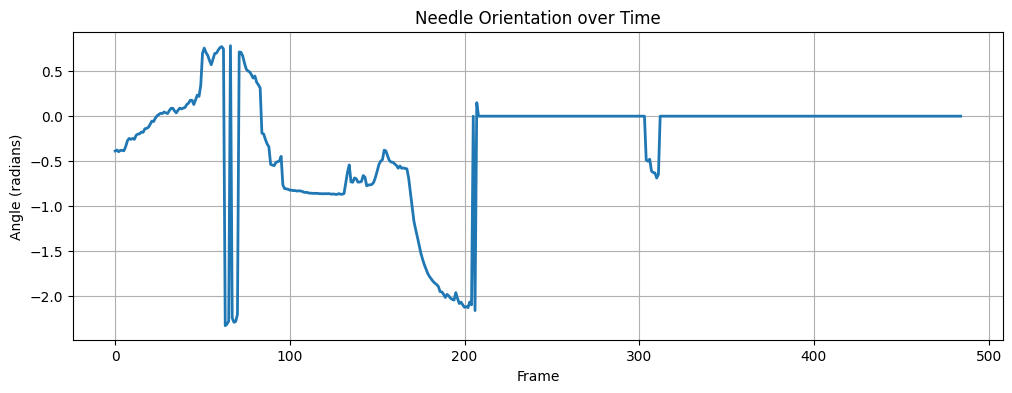

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(angles, linewidth=2)
plt.title("Needle Orientation over Time")
plt.xlabel("Frame")
plt.ylabel("Angle (radians)")
plt.grid(True)
plt.show()

Composite Skill Score

In [ ]:
import numpy as np
from scipy.ndimage import center_of_mass
from sklearn.decomposition import PCA
from scipy.signal import correlate

# ------------------------
# Helper functions
# ------------------------

def mask_centroid(mask: np.ndarray):
    """Return (x, y) centroid from a binary mask, or None if empty."""
    if mask is None or mask.sum() == 0:
        return None
    cy, cx = center_of_mass(mask)
    return float(cx), float(cy)

def mask_orientation(mask: np.ndarray):
    """Return needle orientation angle (radians) using PCA, or None if not enough pixels."""
    y, x = np.where(mask)
    if len(x) < 2:
        return None
    pts = np.column_stack([x, y])
    pca = PCA(n_components=2).fit(pts)
    vx, vy = pca.components_[0]
    angle = np.arctan2(vy, vx)
    return float(angle)

def compute_motion_stats(points: np.ndarray, fps: float):
    """
    points: (N, 2) array of (x, y) in pixel coordinates, ordered in time
    fps: frames per second
    Returns: path_length, speed, speed_std, jerk_mean
    """
    if len(points) < 3:
        return 0.0, 0.0, 0.0, 0.0

    # Displacement per frame (in pixels)
    diffs = np.diff(points, axis=0)
    distances = np.linalg.norm(diffs, axis=1)  # length N-1

    path_length = float(distances.sum())
    mean_speed = float(distances.mean() * fps)      # px/s
    speed_std = float(distances.std() * fps)        # px/s variability

    # Acceleration (frame^-2)
    acceleration = np.diff(distances) * fps
    if len(acceleration) > 1:
        jerk = np.diff(acceleration) * fps
        jerk_mean = float(np.mean(np.abs(jerk)))
    else:
        jerk_mean = 0.0

    return path_length, mean_speed, speed_std, jerk_mean


# ------------------------
# Main metric function
# ------------------------

def compute_suture_metrics(
    needle_masks,
    forceps_masks,
    tissue_mask=None,        # Optional: 2D tissue region mask
    fps: float = 30.0,
    ref_midline_x: float = None  # Optional: ideal midline x for entry/exit
):
    """
    needle_masks:  list/array of (H, W) bool or 0/1 masks, one per frame
    forceps_masks: same as above (or None if not available)
    tissue_mask:   optional (H, W) bool mask defining tissue region
    fps:           frames per second of video
    ref_midline_x: optional reference x-position (e.g., vessel midline) for deviation

    Returns: dict of metrics (needle, forceps, interaction)
    """

    # 1) Collect per-frame centroids & orientations
    needle_centroids = []
    needle_orientations = []
    forceps_centroids = []

    for i, nm in enumerate(needle_masks):
        nm = np.asarray(nm).astype(bool)
        c = mask_centroid(nm)
        o = mask_orientation(nm)
        needle_centroids.append(c)
        needle_orientations.append(o)

    if forceps_masks is not None:
        for fm in forceps_masks:
            fm = np.asarray(fm).astype(bool)
            c = mask_centroid(fm)
            forceps_centroids.append(c)

    # Filter out None for needle trajectory stats
    valid_needle = [c for c in needle_centroids if c is not None]
    valid_needle = np.array(valid_needle, dtype=float) if valid_needle else np.empty((0, 2))

    # Orientation variability
    valid_orient = [o for o in needle_orientations if o is not None]
    orientation_variability = float(np.std(valid_orient)) if len(valid_orient) > 1 else 0.0

    # 2) Needle motion metrics
    if len(valid_needle) >= 3:
        path_length, mean_speed, speed_std, jerk_mean = compute_motion_stats(valid_needle, fps)
    else:
        path_length = mean_speed = speed_std = jerk_mean = 0.0

    stitch_duration_sec = len(needle_masks) / fps  # single stitch duration

    # 3) Entry/Exit deviation (if midline known)
    #    We approximate entry as centroid when needle first intersects tissue,
    #    exit as centroid at last tissue intersection.
    # entry_dev = exit_dev = None
    # if tissue_mask is not None and ref_midline_x is not None:
    #     tissue_mask = np.asarray(tissue_mask).astype(bool)
    #     entry_frames = []
    #     exit_frames = []
    #     for idx, nm in enumerate(needle_masks):
    #         nm = np.asarray(nm).astype(bool)
    #         inside = np.logical_and(nm, tissue_mask)
    #         if inside.sum() > 0:
    #             entry_frames.append(idx)
    #             exit_frames.append(idx)
    #     if entry_frames:
    #         first_idx = entry_frames[0]
    #         last_idx = exit_frames[-1]
    #         c_entry = needle_centroids[first_idx]
    #         c_exit = needle_centroids[last_idx]
    #         if c_entry is not None:
    #             entry_dev = float(abs(c_entry[0] - ref_midline_x))  # x deviation
    #         if c_exit is not None:
    #             exit_dev = float(abs(c_exit[0] - ref_midline_x))

    # 4) Stitch spacing consistency
    #    If you had multiple stitches, you’d detect multiple entry points along tissue.
    #    For a single-stitch sequence, this is usually not applicable.
    # stitch_spacing_std = None  # placeholder for future multi-stitch extension

    # 5) Forceps-related metrics (if masks are provided)
    forceps_metrics = {}
    interaction_metrics = {}

    if forceps_masks is not None and len(forceps_centroids) > 0:
        # Align needle & forceps trajectories in time
        min_len = min(len(needle_centroids), len(forceps_centroids))
        n_pts = np.array([c if c is not None else (np.nan, np.nan) for c in needle_centroids[:min_len]])
        f_pts = np.array([c if c is not None else (np.nan, np.nan) for c in forceps_centroids[:min_len]])

        # Drop frames where one is missing
        valid = ~np.isnan(n_pts[:, 0]) & ~np.isnan(f_pts[:, 0])
        n_valid = n_pts[valid]
        f_valid = f_pts[valid]

        if len(n_valid) > 1:
            # Distance
            distances = np.linalg.norm(n_valid - f_valid, axis=1)
            mean_dist = float(distances.mean())
            std_dist = float(distances.std())

            # Contact ratio (frames where both present)
            contact_ratio = float(valid.sum() / len(valid) * 100.0)

            # Synchronization lag via cross-correlation on speed
            n_speed = np.linalg.norm(np.diff(n_valid, axis=0), axis=1)
            f_speed = np.linalg.norm(np.diff(f_valid, axis=0), axis=1)
            # remove mean
            n_speed_z = n_speed - n_speed.mean()
            f_speed_z = f_speed - f_speed.mean()
            corr = correlate(n_speed_z, f_speed_z, mode="full")
            lag_idx = np.argmax(corr) - (len(f_speed_z) - 1)
            lag_sec = lag_idx / fps

            forceps_metrics = {
                "mean_forceps_distance_px": mean_dist,
                "std_forceps_distance_px": std_dist,
            }
            interaction_metrics = {
                "contact_ratio_percent": contact_ratio,
                "sync_lag_sec": lag_sec,
            }

    metrics = {
        "needle": {
            "path_length_px": path_length,
            "mean_speed_px_per_s": mean_speed,
            "movement_smoothness_px_per_s_std": speed_std,
            "mean_jerk": jerk_mean,
            "orientation_variability_rad": orientation_variability,
            "stitch_duration_sec": stitch_duration_sec,
            # "entry_deviation_px": entry_dev,
            # "exit_deviation_px": exit_dev,
            # "stitch_spacing_std_px": stitch_spacing_std,
            # "trajectory_points": valid_needle.tolist(),
        },
        "forceps": forceps_metrics,
        "interaction": interaction_metrics,
    }
    print(metrics)
    return metrics


Normalize compute skill

In [ ]:
import numpy as np

def normalize(value, good, bad):
    """
    Normalize a metric so lower is better.
    good = target value for expert performance
    bad = threshold for poor performance
    """
    if value is None:
        return 0.0
    score = 100 * (1 - (value - good) / (bad - good))
    return float(np.clip(score, 0, 100))


def compute_skill_score(metrics):
    N = metrics["needle"]
    F = metrics["forceps"]
    I = metrics["interaction"]

    # --------------------------
    # Needle Handling (40%)
    # --------------------------
    s_path_len   = normalize(N["path_length_px"], 3500, 800)
    s_smooth     = normalize(N["movement_smoothness_px_per_s_std"], 60, 20)
    s_jerk       = normalize(N["mean_jerk"], 10, 5)
    s_orient     = normalize(N["orientation_variability_rad"], 0.2, 0.1)

    # # Entry/Exit (if provided)
    # s_entry = normalize(N["entry_deviation_px"], 0, 40) if N["entry_deviation_px"] else 70
    # s_exit  = normalize(N["exit_deviation_px"], 0, 40) if N["exit_deviation_px"] else 70

    needle_score = np.mean([s_path_len, s_smooth, s_jerk, s_orient])

    # --------------------------
    # Forceps Handling (30%)
    # --------------------------
    if F:
        # Ideal forceps–needle distance ~20–40 px
        s_dist      = normalize(F["mean_forceps_distance_px"], 150, 60)
        s_dist_var  = normalize(F["std_forceps_distance_px"], 10, 80)
        forceps_score = np.mean([s_dist, s_dist_var])
    else:
        forceps_score = 50  # not available → neutral

    # --------------------------
    # Coordination / Bimanual Interaction (30%)
    # --------------------------
    if I:
        s_contact = normalize(100 - I["contact_ratio_percent"], 85, 10) # high contact = good
        # ideal sync lag = 0–0.1s
        s_lag = normalize(abs(I["sync_lag_sec"]), 0.1, 0.05)
        interaction_score = np.mean([s_contact, s_lag])
    else:
        interaction_score = 50

    # --------------------------
    # FINAL WEIGHTED SCORE
    # --------------------------
    final_score = (
        0.40 * needle_score +
        0.30 * forceps_score +
        0.30 * interaction_score
    )

    return {
        "needle_score": float(needle_score),
        "forceps_score": float(forceps_score),
        "interaction_score": float(interaction_score),
        "final_skill_score": float(final_score)
    }


In [ ]:
def skill_level(score):
    if score >= 85:
        return "Expert"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Moderate"
    else:
        return "Poor"

In [ ]:
def osats_rating(score):
    if score >= 90: return 5
    if score >= 75: return 4
    if score >= 60: return 3
    if score >= 45: return 2
    return 1

In [ ]:
metrics = compute_suture_metrics(
    needle_masks,
    forceps_masks,
    # tissue_mask=None,
    fps=1.0,
    ref_midline_x=960
)

scores = compute_skill_score(metrics)

print("Needle:", scores["needle_score"])
print("Forceps:", scores["forceps_score"])
print("Interaction:", scores["interaction_score"])
print("FINAL SCORE:", scores["final_skill_score"])

print("Skill Level:", skill_level(scores["final_skill_score"]))
print("OSATS Rating:", osats_rating(scores["final_skill_score"]))


{'needle': {'path_length_px': 7446.516213962453, 'mean_speed_px_per_s': 34.7968047381423, 'movement_smoothness_px_per_s_std': 121.36470023132522, 'mean_jerk': 43.55871230724079, 'orientation_variability_rad': 1.0309805877978153, 'stitch_duration_sec': 485.0}, 'forceps': {'mean_forceps_distance_px': 643.980811846189, 'std_forceps_distance_px': 104.07229681332609}, 'interaction': {'contact_ratio_percent': 37.11340206185567, 'sync_lag_sec': np.float64(0.0)}}
Needle: 100.0
Forceps: 50.0
Interaction: 35.25773195876288
FINAL SCORE: 65.57731958762886
Skill Level: Moderate
OSATS Rating: 3


In [ ]:
metrics

{'needle': {'path_length_px': 7446.516213962453,
  'mean_speed_px_per_s': 34.7968047381423,
  'movement_smoothness_px_per_s_std': 121.36470023132522,
  'mean_jerk': 43.55871230724079,
  'orientation_variability_rad': 1.0309805877978153,
  'stitch_duration_sec': 485.0},
 'forceps': {'mean_forceps_distance_px': 643.980811846189,
  'std_forceps_distance_px': 104.07229681332609},
 'interaction': {'contact_ratio_percent': 37.11340206185567,
  'sync_lag_sec': np.float64(0.0)}}